In [ ]:
import tensorflow as tf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from tensorflow import keras


In [16]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train.shape

(50000, 32, 32, 3)

In [17]:
y_train.shape

(50000, 1)

In [18]:
x_test.shape

(10000, 32, 32, 3)

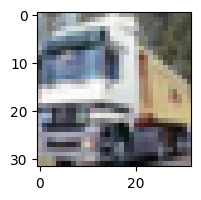

In [11]:
def plot_sample(index):
    plt.figure(figsize=(15,2))
    plt.imshow(x_train[index])
plot_sample(1)

In [ ]:
x_train= x_train/255      #normalization
x_test= x_test/255

In [13]:
x_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [ ]:
# ANN model

model= keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    #keras.layers.Dense(3000, activation= 'relu'),
    keras.layers.Dense(1000, activation= 'relu'),
    keras.layers.Dense(10, activation= 'sigmoid')
])

model.compile(optimizer='SGD', loss= 'sparse_categorical_crossentropy', metrics=['accuracy'])
# loss is categorical entropy because the y in hot encoded

model.fit(x_train, y_train, epochs=10)


Epoch 1/10


1563/1563 [==============================] - 12s 7ms/step - loss: 5761.3848 - accuracy: 0.0965
Epoch 2/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.3028 - accuracy: 0.0981
Epoch 3/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.3028 - accuracy: 0.0964
Epoch 4/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.3027 - accuracy: 0.0986
Epoch 5/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.3027 - accuracy: 0.0998
Epoch 6/10
1563/1563 [==============================] - 10s 7ms/step - loss: 2.3027 - accuracy: 0.0969
Epoch 7/10
1563/1563 [==============================] - 11s 7ms/step - loss: 2.3027 - accuracy: 0.0985
Epoch 8/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.3026 - accuracy: 0.1004
Epoch 9/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.3027 - accuracy: 0.0979
Epoch 10/10
1563/1563 [==============================] - 10s 6ms/ste

In [21]:
model.evaluate(x_test,y_test)

313/313 [==============================] - 1s 4ms/step - loss: 2.3446 - accuracy: 0.1000


[2.344573974609375, 0.10000000149011612]

In [2]:
#CNN model
from keras import layers, models
cnn = models.Sequential([
     #cnn
    layers.Conv2D(filters=32,kernel_size=(3,3), activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(filters=64,kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    #cnn
    # dense
    layers.Flatten(),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(10, activation= 'softmax')
])



In [3]:
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 2304)              0         
                                                                 
 dense (Dense)               (None, 64)                1

In [ ]:
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

cnn.fit(x_train, y_train, epochs=10)

In [31]:
cnn.evaluate(x_test, y_test)

313/313 [==============================] - 2s 6ms/step - loss: 1.1427 - accuracy: 0.6534


[1.142694354057312, 0.6534000039100647]

In [32]:
y_pred= cnn.predict(x_test)
y_pred[0:5]

313/313 [==============================] - 2s 6ms/step


array([[1.5839204e-03, 2.8401828e-05, 1.6385426e-03, 6.7632222e-01,
        5.9387501e-04, 1.5415923e-01, 4.3070740e-03, 9.2754228e-04,
        1.6043545e-01, 3.6658760e-06],
       [2.4192048e-04, 8.1430599e-02, 4.6550135e-06, 1.6942282e-06,
        2.4698091e-05, 1.6734754e-07, 4.6112132e-06, 2.5831898e-08,
        9.1741800e-01, 8.7360363e-04],
       [3.5775702e-02, 3.3014074e-01, 3.1681165e-02, 1.1617933e-01,
        3.1500194e-02, 3.9956730e-02, 9.0879612e-03, 1.0840844e-01,
        1.2779631e-01, 1.6947350e-01],
       [9.9098819e-01, 5.8126776e-03, 2.4239235e-03, 4.9696413e-05,
        4.0586474e-06, 1.0489519e-05, 6.9962939e-06, 2.4025167e-06,
        6.5563223e-04, 4.6013029e-05],
       [5.8618566e-04, 2.9546836e-02, 3.9454545e-03, 2.1314370e-02,
        8.8917965e-01, 1.7965733e-03, 4.9120169e-02, 9.3196315e-05,
        3.6939126e-03, 7.2368834e-04]], dtype=float32)

In [33]:
y_pred= [np.argmax(i) for i in y_pred]
y_pred[0:5]

[3, 8, 1, 0, 4]

In [ ]:
y_test[0:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

In [36]:
from sklearn. metrics import accuracy_score, classification_report, confusion_matrix
accuracy_score(y_test,y_pred)

0.6534

In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.68      0.76      0.72      1000
           1       0.76      0.79      0.78      1000
           2       0.55      0.50      0.52      1000
           3       0.47      0.47      0.47      1000
           4       0.60      0.57      0.59      1000
           5       0.53      0.58      0.56      1000
           6       0.69      0.77      0.73      1000
           7       0.68      0.70      0.69      1000
           8       0.80      0.68      0.74      1000
           9       0.78      0.71      0.74      1000

    accuracy                           0.65     10000
   macro avg       0.66      0.65      0.65     10000
weighted avg       0.66      0.65      0.65     10000



Handwritten using CNN

In [38]:
(x_train, y_train) ,(x_test, y_test) = keras.datasets.mnist.load_data()

In [39]:
x_train.shape

(60000, 28, 28)

In [40]:
y_test.shape

(10000,)

In [ ]:
x_train[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [42]:
x_train= x_train/255
x_test= x_test /255

In [46]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [53]:
cnn1= keras.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), input_shape=(28,28,1), activation='relu'),
    layers.MaxPool2D(2,2),
    
    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

cnn1.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 20s 10ms/step - loss: 0.1579 - accuracy: 0.9541
Epoch 2/10
1875/1875 [==============================] - 18s 9ms/step - loss: 0.0545 - accuracy: 0.9835
Epoch 3/10
1875/1875 [==============================] - 19s 10ms/step - loss: 0.0366 - accuracy: 0.9887
Epoch 4/10
1875/1875 [==============================] - 19s 10ms/step - loss: 0.0250 - accuracy: 0.9920
Epoch 5/10
1875/1875 [==============================] - 19s 10ms/step - loss: 0.0170 - accuracy: 0.9945
Epoch 6/10
1875/1875 [==============================] - 19s 10ms/step - loss: 0.0125 - accuracy: 0.9961
Epoch 7/10
1875/1875 [==============================] - 20s 10ms/step - loss: 0.0102 - accuracy: 0.9969
Epoch 8/10
1875/1875 [==============================] - 19s 10ms/step - loss: 0.0078 - accuracy: 0.9970
Epoch 9/10
1875/1875 [==============================] - 19s 10ms/step - loss: 0.0047 - accuracy: 0.9984
Epoch 10/10
1875/1875 [==============================] - 19s 10ms

In [54]:
cnn1.evaluate(x_train,y_train)

1875/1875 [==============================] - 7s 4ms/step - loss: 0.0037 - accuracy: 0.9987


[0.0036635389551520348, 0.9986666440963745]

In [55]:
cnn1.evaluate(x_test,y_test)

313/313 [==============================] - 2s 4ms/step - loss: 0.0515 - accuracy: 0.9856


[0.051465388387441635, 0.9855999946594238]